In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score


In [2]:
import sys
from packaging import version
import sklearn

# Check Python version
if sys.version_info < (3, 7):
    raise ValueError(f"Python version must be 3.7 or higher. Found: {sys.version_info.major}.{sys.version_info.minor}")

# Check Scikit-learn version
if version.parse(sklearn.__version__) < version.parse("1.0.1"):
    raise ValueError(f"Scikit-learn version must be 1.0.1 or higher. Found: {sklearn.__version__}")

print("Environment checks passed: Python and Scikit-learn versions meet requirements.")

Environment checks passed: Python and Scikit-learn versions meet requirements.


In [3]:

from pathlib import Path  # Importing the Path class from the pathlib module to handle file system paths
import pandas as pd  # Importing pandas as pd for data manipulation and analysis
import tarfile  # Importing the tarfile module to work with tar archive files
import urllib.request  # Importing urllib.request to handle URL operations


In [4]:
def load_bitcoin_data():
    bitcoin_path = Path("btcusd_1-min_data.csv")

    if not bitcoin_path.is_file():
       print("NOT FOUND")
        
    return pd.read_csv(Path("btcusd_1-min_data.csv"))

bitcoin = load_bitcoin_data()
print("Bitcoin data loaded successfully.")

Bitcoin data loaded successfully.


In [5]:
bitcoin.head()

,Timestamp,Open,High,Low,Close,Volume
0,1.325412e+09,4.58,4.58,4.58,4.58,0.0
1,1.325412e+09,4.58,4.58,4.58,4.58,0.0
2,1.325412e+09,4.58,4.58,4.58,4.58,0.0
3,1.325412e+09,4.58,4.58,4.58,4.58,0.0
4,1.325412e+09,4.58,4.58,4.58,4.58,0.0


In [6]:
# Convert timestamp to datetime
bitcoin['Timestamp'] = pd.to_datetime(bitcoin['Timestamp'], unit='s')
bitcoin = bitcoin.sort_values('Timestamp').reset_index(drop=True)

# Drop rows with NaN values (common in raw OHLCV data)
bitcoin.dropna(inplace=True)

# Feature engineering - create useful features from OHLCV data
def engineer_features(df):
    df = df.copy()
    
    # Price movement features
    df['price_range'] = df['High'] - df['Low']           # candle range
    df['price_change'] = df['Close'] - df['Open']        # candle body
    df['price_change_pct'] = df['price_change'] / df['Open']
    
    # Rolling window features (momentum/trend)
    df['close_lag_1']  = df['Close'].shift(1)
    df['close_lag_5']  = df['Close'].shift(5)
    df['close_lag_10'] = df['Close'].shift(10)
    df['close_lag_30'] = df['Close'].shift(30)
    
    df['rolling_mean_5']  = df['Close'].rolling(window=5).mean()
    df['rolling_mean_10'] = df['Close'].rolling(window=10).mean()
    df['rolling_mean_30'] = df['Close'].rolling(window=30).mean()
    
    df['rolling_std_5']  = df['Close'].rolling(window=5).std()
    df['rolling_std_10'] = df['Close'].rolling(window=10).std()
    
    df['volume_lag_1'] = df['Volume'].shift(1)
    df['rolling_volume_5'] = df['Volume'].rolling(window=5).mean()
    
    # Time features
    df['hour']       = df['Timestamp'].dt.hour
    df['dayofweek']  = df['Timestamp'].dt.dayofweek
    df['month']      = df['Timestamp'].dt.month
    
    # Target: next minute's closing price
    df['target'] = df['Close'].shift(-1)
    
    df.dropna(inplace=True)
    return df

bitcoin = engineer_features(bitcoin)
print(bitcoin.shape)
bitcoin.head()

(7563988, 24)


,Timestamp,Open,High,Low,Close,Volume,price_range,price_change,price_change_pct,close_lag_1,...,rolling_mean_10,rolling_mean_30,rolling_std_5,rolling_std_10,volume_lag_1,rolling_volume_5,hour,dayofweek,month,target
30,2012-01-01 10:31:00,4.58,4.58,4.58,4.58,0.0,0.0,0.0,0.0,4.58,...,4.58,4.58,0.0,0.0,0.0,0.0,10,6,1,4.58
31,2012-01-01 10:32:00,4.58,4.58,4.58,4.58,0.0,0.0,0.0,0.0,4.58,...,4.58,4.58,0.0,0.0,0.0,0.0,10,6,1,4.58
32,2012-01-01 10:33:00,4.58,4.58,4.58,4.58,0.0,0.0,0.0,0.0,4.58,...,4.58,4.58,0.0,0.0,0.0,0.0,10,6,1,4.58
33,2012-01-01 10:34:00,4.58,4.58,4.58,4.58,0.0,0.0,0.0,0.0,4.58,...,4.58,4.58,0.0,0.0,0.0,0.0,10,6,1,4.58
34,2012-01-01 10:35:00,4.58,4.58,4.58,4.58,0.0,0.0,0.0,0.0,4.58,...,4.58,4.58,0.0,0.0,0.0,0.0,10,6,1,4.58


In [7]:
# Use last 20% as test set (preserving time order - important for time series!)
split_idx = int(len(bitcoin) * 0.8)

train_set = bitcoin.iloc[:split_idx].copy()
test_set  = bitcoin.iloc[split_idx:].copy()

print(f"Train size: {len(train_set)}, Test size: {len(test_set)}")

FEATURE_COLS = [
    'Open', 'High', 'Low', 'Close', 'Volume',
    'price_range', 'price_change', 'price_change_pct',
    'close_lag_1', 'close_lag_5', 'close_lag_10', 'close_lag_30',
    'rolling_mean_5', 'rolling_mean_10', 'rolling_mean_30',
    'rolling_std_5', 'rolling_std_10',
    'volume_lag_1', 'rolling_volume_5',
    'hour', 'dayofweek', 'month'
]
TARGET = 'target'

X_train = train_set[FEATURE_COLS]
y_train = train_set[TARGET]

X_test = test_set[FEATURE_COLS]
y_test = test_set[TARGET]

Train size: 6051190, Test size: 1512798


In [8]:
# Linear Regression
lin_reg = make_pipeline(StandardScaler(), LinearRegression())
lin_reg.fit(X_train, y_train)

lin_preds = lin_reg.predict(X_train)
lin_rmse  = np.sqrt(mean_squared_error(y_train, lin_preds))
print(f"Linear Regression Train RMSE: {lin_rmse:.2f}")

# Random Forest
forest_reg = make_pipeline(
    StandardScaler(),
    RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
)
forest_reg.fit(X_train, y_train)

forest_preds = forest_reg.predict(X_train)
forest_rmse  = np.sqrt(mean_squared_error(y_train, forest_preds))
print(f"Random Forest Train RMSE: {forest_rmse:.2f}")

Linear Regression Train RMSE: 20.81
Random Forest Train RMSE: 22.87



Linear Regression CV RMSE:  mean=17.40, std=14.85
Random Forest CV RMSE:       mean=3954.14, std=5555.02


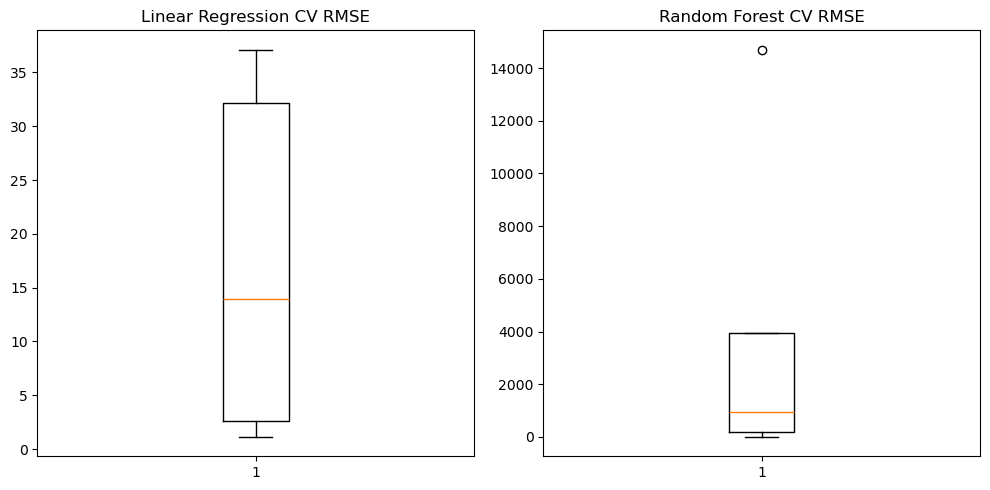

In [9]:
# NOTE: For time series, ideally use TimeSeriesSplit instead of random CV
# Using a small cv=3 to keep runtime reasonable on large datasets
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

lin_cv = -cross_val_score(lin_reg, X_train, y_train,
                           scoring='neg_root_mean_squared_error', cv=tscv)
forest_cv = -cross_val_score(forest_reg, X_train, y_train,
                              scoring='neg_root_mean_squared_error', cv=tscv)

print(f"\nLinear Regression CV RMSE:  mean={lin_cv.mean():.2f}, std={lin_cv.std():.2f}")
print(f"Random Forest CV RMSE:       mean={forest_cv.mean():.2f}, std={forest_cv.std():.2f}")

# Boxplot comparison
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].boxplot(lin_cv);    axes[0].set_title('Linear Regression CV RMSE')
axes[1].boxplot(forest_cv); axes[1].set_title('Random Forest CV RMSE')
plt.tight_layout(); plt.show()

In [ ]:
# Combine train predictions too
train_preds = forest_reg.predict(X_train)

plt.figure(figsize=(20, 6))

# Training period
plt.plot(train_set['Timestamp'], y_train,      label='Actual (train)',    
         alpha=0.6, linewidth=0.6, color='steelblue')
plt.plot(train_set['Timestamp'], train_preds,  label='Predicted (train)', 
         alpha=0.6, linewidth=0.6, color='orange')

# Test period
plt.plot(test_set['Timestamp'],  y_test,        label='Actual (test)',    
         alpha=0.8, linewidth=0.8, color='blue')
plt.plot(test_set['Timestamp'],  final_preds,   label='Predicted (test)', 
         alpha=0.8, linewidth=0.8, color='red')

# Vertical line separating train/test
plt.axvline(test_set['Timestamp'].iloc[0], color='black', 
            linestyle='--', linewidth=1, label='Train/Test split')

plt.title('Bitcoin Price: Full History — Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend(loc="upper left")
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()